In [1]:
# Imports
import os
import time
import random
import math
import json
from pathlib import Path
from typing import Dict, Any, Optional

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torch.cuda.amp import GradScaler, autocast

from torchvision import datasets, transforms, models

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [2]:
# Device configuration
use_cuda = torch.cuda.is_available()
device = torch.device('cuda' if use_cuda else 'cpu')
if use_cuda:
    torch.backends.cudnn.benchmark = True
print('CUDA available:', use_cuda)
print('Device:', device)
print('GPU count:', torch.cuda.device_count())
if use_cuda:
    print('GPU name:', torch.cuda.get_device_name(0))

CUDA available: True
Device: cuda
GPU count: 1
GPU name: NVIDIA GeForce RTX 4080 SUPER


In [3]:
class CFG:
    data_dir = '/content/Resized_Dataset'
    disease_types = ['No Fibrosis','Portal Fibrosis','Periportal Fibrosis','Septal Fibrosis','Cirrhosis']
    image_size = 256
    batch_size = 32
    num_workers = 0
    epochs = 50
    lr = 1e-3
    weight_decay = 1e-4
    early_stop_patience = 8
    min_delta = 1e-4
    val_split = 0.15
    test_split = 0.15
    use_augment = False  # mirrors "without augmentation" benchmark
    checkpoint_path = 'best_model.pt'
    fp16 = True
    lambda_phys = 0.1  # weight for physics-informed loss

print('Classes:', CFG.disease_types)


Classes: ['No Fibrosis', 'Portal Fibrosis', 'Periportal Fibrosis', 'Septal Fibrosis', 'Cirrhosis']


In [4]:
from pathlib import Path

rows = []
base = Path(CFG.data_dir)
for cls_id, cls in enumerate(CFG.disease_types):
    cls_dir = base/cls
    if not cls_dir.exists():
        continue
    for p in cls_dir.glob('*'):
        if p.suffix.lower() in {'.jpg','.jpeg','.png','.bmp','.tif','.tiff'}:
            rows.append({'File': f'{cls}/{p.name}', 'DiseaseID': cls_id, 'Disease Type': cls})

train_df = pd.DataFrame(rows)
print(train_df.head(3))
print('Total images:', len(train_df))


                    File  DiseaseID Disease Type
0   No Fibrosis/a197.jpg          0  No Fibrosis
1  No Fibrosis/a3957.jpg          0  No Fibrosis
2    No Fibrosis/j90.jpg          0  No Fibrosis
Total images: 6343


In [5]:
import torch.multiprocessing as mp
mp.set_sharing_strategy("file_system")

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

base_transforms = [
    transforms.Resize((CFG.image_size, CFG.image_size)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
]

if CFG.use_augment:
    train_transforms = transforms.Compose([
        transforms.Resize((CFG.image_size, CFG.image_size)),
        transforms.Grayscale(num_output_channels=3),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=7),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std),
    ])
else:
    train_transforms = transforms.Compose(base_transforms)

val_test_transforms = transforms.Compose(base_transforms)

full_ds_plain = datasets.ImageFolder(root=CFG.data_dir)
class_to_idx = full_ds_plain.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}

labels = np.array([full_ds_plain.samples[i][1] for i in range(len(full_ds_plain))])
indices = np.arange(len(full_ds_plain))

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=CFG.test_split, random_state=seed)
trainval_idx, test_idx = next(sss1.split(indices, labels))

labels_trainval = labels[trainval_idx]
indices_trainval = indices[trainval_idx]
val_size = CFG.val_split / (1.0 - CFG.test_split)
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=val_size, random_state=seed)
train_idx_rel, val_idx_rel = next(sss2.split(indices_trainval, labels_trainval))
train_idx = indices_trainval[train_idx_rel]
val_idx = indices_trainval[val_idx_rel]

print(f'Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}')

class ImageFolderWithTransform(datasets.ImageFolder):
    def __init__(self, root, transform=None):
        super().__init__(root=root)
        self.transform = transform
    def __getitem__(self, index):
        path, target = self.samples[index]
        sample = self.loader(path)
        if self.transform is not None:
            sample = self.transform(sample)
        return sample, target

train_ds_full = ImageFolderWithTransform(root=CFG.data_dir, transform=train_transforms)
val_ds_full   = ImageFolderWithTransform(root=CFG.data_dir, transform=val_test_transforms)
test_ds_full  = ImageFolderWithTransform(root=CFG.data_dir, transform=val_test_transforms)

train_ds = Subset(train_ds_full, train_idx)
val_ds   = Subset(val_ds_full, val_idx)
test_ds  = Subset(test_ds_full, test_idx)

use_cuda = torch.cuda.is_available()
train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True,  num_workers=CFG.num_workers, pin_memory=use_cuda)
val_loader   = DataLoader(val_ds,   batch_size=CFG.batch_size, shuffle=False, num_workers=CFG.num_workers, pin_memory=use_cuda)
test_loader  = DataLoader(test_ds,  batch_size=CFG.batch_size, shuffle=False, num_workers=CFG.num_workers, pin_memory=use_cuda)

xb, yb = next(iter(train_loader))
print('Batch images shape:', tuple(xb.shape))


Train: 4439, Val: 952, Test: 952
Batch images shape: (32, 3, 256, 256)


In [6]:
import torch
import torch.nn as nn
from torchvision import models

class PhysicsInformedHead(nn.Module):
    def __init__(self, in_features: int, num_classes: int):
        super().__init__()
        self.classifier = nn.Linear(in_features, num_classes)

    def forward(self, feats: torch.Tensor) -> torch.Tensor:
        return self.classifier(feats)

    # Feature-based residual: stable and memory-friendly
    def physics_residual_from_feats(self, feats: torch.Tensor, logits: torch.Tensor) -> torch.Tensor:
        top = torch.logsumexp(logits, dim=1).sum()
        (g,) = torch.autograd.grad(top, feats, create_graph=True, retain_graph=True, allow_unused=False)
        return g.pow(2).mean()

class ResNet50PINN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        try:
            weights = models.ResNet50_Weights.IMAGENET1K_V2
        except Exception:
            weights = 'DEFAULT'
        backbone = models.resnet50(weights=weights)
        self.features = nn.Sequential(*(list(backbone.children())[:-1]))  # up to GAP
        in_features = backbone.fc.in_features
        self.head = PhysicsInformedHead(in_features, num_classes)

    def forward(self, x: torch.Tensor):
        feats = self.features(x)          # [B, C, 1, 1]
        feats = feats.flatten(1)          # [B, C]
        logits = self.head(feats)         # [B, K]
        return logits, feats


In [7]:
# ===== Shared Training Utilities (baseline vs physics-informed) =====
import copy
from sklearn.metrics import accuracy_score, f1_score

def train_one_epoch_shared(model, loader, optimizer, criterion, scaler, device,
                           use_physics: bool, lambda_phys: float):
    model.train()
    loss_sum = 0.0; acc_sum = 0.0; n = 0
    phys_sum = 0.0; phys_n = 0
    for imgs, lbls in loader:
        imgs = imgs.to(device, non_blocking=True)
        lbls = lbls.to(device, non_blocking=True)

        # No need to require_grad on inputs when using feature-based residual
        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=scaler.is_enabled()):
            logits, feats = model(imgs)
            ce = criterion(logits, lbls)

            if use_physics and lambda_phys > 0:
                # Feature-based residual (keeps graph connected and memory-friendly)
                top = torch.logsumexp(logits, dim=1).sum()
                (g,) = torch.autograd.grad(top, feats, create_graph=True, retain_graph=True, allow_unused=False)
                phys = g.pow(2).mean()
                loss = ce + lambda_phys * phys
                bs = imgs.size(0)
                phys_sum += float(phys.item()) * bs
                phys_n   += bs
            else:
                loss = ce

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        bs = imgs.size(0)
        loss_sum += loss.item() * bs
        acc_sum  += (logits.detach().argmax(1) == lbls).float().mean().item() * bs
        n += bs
    phys_avg = (phys_sum/phys_n) if phys_n > 0 else None
    return loss_sum / n, acc_sum / n, phys_avg

def validate_shared(model, loader, criterion, device,
                    use_physics_in_val: bool = False, lambda_phys: float = 0.0):
    # model.eval() keeps BN/Dropout deterministic while still allowing grads if needed
    model.eval()
    loss_sum = 0.0; acc_sum = 0.0; n = 0
    phys_sum = 0.0; phys_n = 0
    for imgs, lbls in loader:
        imgs = imgs.to(device, non_blocking=True)
        lbls = lbls.to(device, non_blocking=True)

        # Forward once
        logits, feats = model(imgs)
        ce = criterion(logits, lbls)

        if use_physics_in_val and lambda_phys > 0:
            # Re-enable grads locally for physics residual only
            with torch.enable_grad():
                # Recompute a tiny graph for the phys scalar to get gradients
                logits2, feats2 = model(imgs)  # small extra forward to ensure grad_fn is present
                top = torch.logsumexp(logits2, dim=1).sum()
                (g2,) = torch.autograd.grad(top, feats2, create_graph=False, retain_graph=False, allow_unused=False)
                phys = g2.pow(2).mean()
            loss = ce + lambda_phys * phys
            bs = imgs.size(0)
            phys_sum += float(phys.item()) * bs
            phys_n   += bs
        else:
            loss = ce  # CE-only validation (fast, grad-free)

        bs = imgs.size(0)
        loss_sum += loss.item() * bs
        acc_sum  += (logits.argmax(1) == lbls).float().mean().item() * bs
        n += bs
    val_phys = (phys_sum/phys_n) if phys_n > 0 else None
    return loss_sum / n, acc_sum / n, val_phys

def train_full_run(use_physics: bool, lambda_phys: float,
                   epochs: int = CFG.epochs, verbose: bool = True,
                   use_physics_in_val: bool = False):
    # Fresh model/optim each run for fair comparison
    model = ResNet50PINN(num_classes=len(CFG.disease_types)).to(device)
    optimizer = optim.Adam(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=verbose)
    scaler = GradScaler(enabled=CFG.fp16 and torch.cuda.is_available())
    criterion = nn.CrossEntropyLoss()

    best_val_loss = float('inf'); best_epoch = -1; no_improve = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'train_phys': [], 'val_phys': []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc, tr_phys = train_one_epoch_shared(model, train_loader, optimizer, criterion, scaler, device,
                                                          use_physics=use_physics, lambda_phys=lambda_phys)
        va_loss, va_acc, va_phys = validate_shared(model, val_loader, criterion, device,
                                                   use_physics_in_val=False, lambda_phys=lambda_phys)
        scheduler.step(va_loss)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)
        history['train_phys'].append(tr_phys if tr_phys is not None else np.nan)
        history['val_phys'].append(va_phys if va_phys is not None else np.nan)

        if verbose:
            tag = 'PINN' if use_physics and lambda_phys > 0 else 'BASE'
            print(f"[{tag}] Epoch {epoch:03d}/{epochs} | "
                  f"train_loss={tr_loss:.4f}, train_acc={tr_acc:.4f} | "
                  f"val_loss={va_loss:.4f}, val_acc={va_acc:.4f} | time={(time.time()-t0):.1f}s")

        improved = (best_val_loss - va_loss) > CFG.min_delta
        if improved:
            best_val_loss = va_loss
            best_epoch = epoch
            no_improve = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            no_improve += 1

        if no_improve >= CFG.early_stop_patience:
            if verbose:
                print(f"Early stopping at epoch {epoch}, best epoch={best_epoch} val_loss={best_val_loss:.4f}")
            break

    if 'best_state' in locals():
        model.load_state_dict(best_state)

    # Test evaluation
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs = imgs.to(device, non_blocking=True)
            lbls = lbls.to(device, non_blocking=True)
            logits, _ = model(imgs)
            y_true.extend(lbls.cpu().numpy().tolist())
            y_pred.extend(logits.argmax(1).cpu().numpy().tolist())

    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average='macro')
    if verbose:
        print(f"Test: acc={acc:.4f}, macro-F1={f1m:.4f}")
    return {'model': model, 'history': history,
            'y_true': np.array(y_true), 'y_pred': np.array(y_pred),
            'acc': acc, 'f1_macro': f1m}


In [8]:
# Baseline
res_base = train_full_run(use_physics=False, lambda_phys=0.0, epochs=CFG.epochs, verbose=True,
                          use_physics_in_val=False)

# Physics-informed
res_pinn = train_full_run(use_physics=True, lambda_phys=CFG.lambda_phys, epochs=CFG.epochs, verbose=True,
                          use_physics_in_val=False)  # set True if you want physics in val loss too

print("Baseline  -> acc={:.4f}, f1_macro={:.4f}".format(res_base['acc'], res_base['f1_macro']))
print("PINN      -> acc={:.4f}, f1_macro={:.4f}".format(res_pinn['acc'], res_pinn['f1_macro']))


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
/tmp/ipython-input-7-2242143603.py:86: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=CFG.fp16 and torch.cuda.is_available())
/tmp/ipython-input-7-2242143603.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=scaler.is_enabled()):


[BASE] Epoch 001/50 | train_loss=0.7917, train_acc=0.6551 | val_loss=0.8418, val_acc=0.6649 | time=16.2s
[BASE] Epoch 002/50 | train_loss=0.5005, train_acc=0.7950 | val_loss=2.9340, val_acc=0.6155 | time=11.4s
[BASE] Epoch 003/50 | train_loss=0.3690, train_acc=0.8461 | val_loss=1.2245, val_acc=0.6975 | time=11.4s
[BASE] Epoch 004/50 | train_loss=0.2967, train_acc=0.8889 | val_loss=1.1419, val_acc=0.6639 | time=11.5s
[BASE] Epoch 005/50 | train_loss=0.1805, train_acc=0.9358 | val_loss=1.6229, val_acc=0.7269 | time=11.4s
[BASE] Epoch 006/50 | train_loss=0.0640, train_acc=0.9797 | val_loss=0.3714, val_acc=0.8792 | time=11.4s
[BASE] Epoch 007/50 | train_loss=0.0222, train_acc=0.9935 | val_loss=0.4948, val_acc=0.8697 | time=11.5s
[BASE] Epoch 008/50 | train_loss=0.0096, train_acc=0.9971 | val_loss=0.6530, val_acc=0.8624 | time=11.4s
[BASE] Epoch 009/50 | train_loss=0.0137, train_acc=0.9971 | val_loss=0.7625, val_acc=0.8866 | time=11.5s
[BASE] Epoch 010/50 | train_loss=0.0140, train_acc=0.99

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
/tmp/ipython-input-7-2242143603.py:86: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=CFG.fp16 and torch.cuda.is_available())
/tmp/ipython-input-7-2242143603.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=scaler.is_enabled()):


[PINN] Epoch 001/50 | train_loss=0.7366, train_acc=0.6808 | val_loss=0.9859, val_acc=0.5693 | time=11.7s
[PINN] Epoch 002/50 | train_loss=0.4131, train_acc=0.8394 | val_loss=0.4950, val_acc=0.7794 | time=11.7s
[PINN] Epoch 003/50 | train_loss=0.2759, train_acc=0.8982 | val_loss=0.4229, val_acc=0.8288 | time=11.6s
[PINN] Epoch 004/50 | train_loss=0.2132, train_acc=0.9232 | val_loss=1.7902, val_acc=0.6775 | time=11.6s
[PINN] Epoch 005/50 | train_loss=0.1159, train_acc=0.9606 | val_loss=1.3148, val_acc=0.6901 | time=11.5s
[PINN] Epoch 006/50 | train_loss=0.1194, train_acc=0.9590 | val_loss=1.4450, val_acc=0.7311 | time=11.6s
[PINN] Epoch 007/50 | train_loss=0.0791, train_acc=0.9691 | val_loss=0.3475, val_acc=0.8855 | time=11.6s
[PINN] Epoch 008/50 | train_loss=0.0829, train_acc=0.9707 | val_loss=0.2328, val_acc=0.9433 | time=11.7s
[PINN] Epoch 009/50 | train_loss=0.0503, train_acc=0.9827 | val_loss=0.5021, val_acc=0.8666 | time=11.7s
[PINN] Epoch 010/50 | train_loss=0.0986, train_acc=0.96

In [9]:
# Statistical comparison: McNemar + Bootstrap CI (paired on same test split)
import numpy as np

# Expect results from earlier runs:
# res_base = {'y_true': np.array(...), 'y_pred': np.array(...)}
# res_pinn = {'y_true': np.array(...), 'y_pred': np.array(...)}
y_true = res_base['y_true']
yhat_a = res_base['y_pred']   # Baseline predictions
yhat_b = res_pinn['y_pred']   # PINN predictions

assert np.array_equal(y_true, res_pinn['y_true']), "Test labels must match for paired comparison"

# Build McNemar contingency table counts:
# b01: baseline correct, PINN wrong
# b10: baseline wrong, PINN correct
a_correct = (yhat_a == y_true)
b_correct = (yhat_b == y_true)
b01 = int(np.sum((a_correct == 1) & (b_correct == 0)))
b10 = int(np.sum((a_correct == 0) & (b_correct == 1)))

def mcnemar_chi2(b01, b10, continuity=True):
    # Continuity-corrected chi-square: (|b01-b10|-1)^2 / (b01+b10)
    if b01 + b10 == 0:
        return 0.0, 1.0
    if continuity:
        stat = (abs(b01 - b10) - 1)**2 / (b01 + b10)
    else:
        stat = (b01 - b10)**2 / (b01 + b10)
    try:
        from scipy.stats import chi2
        p = chi2.sf(stat, df=1)
    except Exception:
        # Fallback rough tail prob if SciPy unavailable
        p = float(np.exp(-stat / 2.0))
    return float(stat), float(p)

chi2_stat, p_mcnemar = mcnemar_chi2(b01, b10, continuity=True)
print(f"McNemar (continuity): b01={b01}, b10={b10}, chi2={chi2_stat:.4f}, p={p_mcnemar:.6f}")

# If you prefer exact/binomial McNemar (recommended when b01+b10 is small) and have statsmodels:
# from statsmodels.stats.contingency_tables import mcnemar
# table = np.array([[np.sum(a_correct & b_correct),
#                    np.sum(a_correct & ~b_correct)],
#                   [np.sum(~a_correct & b_correct),
#                    np.sum(~a_correct & ~b_correct)]], dtype=int)
# res = mcnemar(table, exact=True)  # exact binomial
# print(f"McNemar exact: stat={res.statistic:.4f}, p={res.pvalue:.6f}")

# Bootstrap CI for accuracy difference (PINN - Baseline) using percentile method
def bootstrap_acc_diff(y_true, ya, yb, n_boot=5000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    a_ok = (ya == y_true).astype(np.float32)
    b_ok = (yb == y_true).astype(np.float32)
    diffs = np.empty(n_boot, dtype=np.float32)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        diffs[i] = b_ok[idx].mean() - a_ok[idx].mean()
    mean = float(np.mean(diffs))
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    return mean, float(lo), float(hi)

mean_diff, lo95, hi95 = bootstrap_acc_diff(y_true, yhat_a, yhat_b, n_boot=5000, seed=42)
print(f"Accuracy diff (PINN - Base): mean={mean_diff:.4f}, 95% CI=({lo95:.4f}, {hi95:.4f})")


McNemar (continuity): b01=10, b10=6, chi2=0.5625, p=0.453255
Accuracy diff (PINN - Base): mean=-0.0041, 95% CI=(-0.0126, 0.0042)


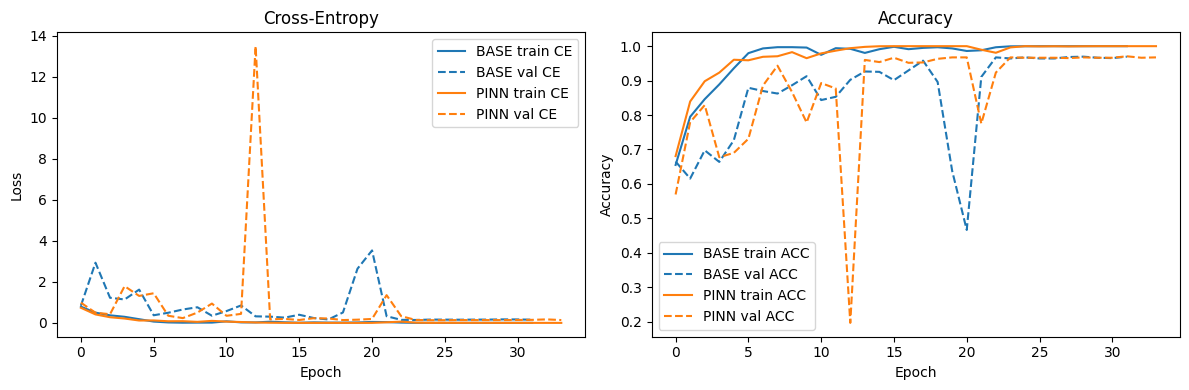

In [10]:
import matplotlib.pyplot as plt

def plot_learning_curves(hist_base, hist_pinn, title_prefix=""):
    # Cross-entropy loss
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(hist_base['train_loss'], label='BASE train CE', color='tab:blue')
    plt.plot(hist_base['val_loss'],   label='BASE val CE',   color='tab:blue', linestyle='--')
    plt.plot(hist_pinn['train_loss'], label='PINN train CE', color='tab:orange')
    plt.plot(hist_pinn['val_loss'],   label='PINN val CE',   color='tab:orange', linestyle='--')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title(f'{title_prefix}Cross-Entropy'); plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(hist_base['train_acc'], label='BASE train ACC', color='tab:blue')
    plt.plot(hist_base['val_acc'],   label='BASE val ACC',   color='tab:blue', linestyle='--')
    plt.plot(hist_pinn['train_acc'], label='PINN train ACC', color='tab:orange')
    plt.plot(hist_pinn['val_acc'],   label='PINN val ACC',   color='tab:orange', linestyle='--')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title(f'{title_prefix}Accuracy'); plt.legend()
    plt.tight_layout(); plt.show()

plot_learning_curves(res_base['history'], res_pinn['history'], title_prefix="")


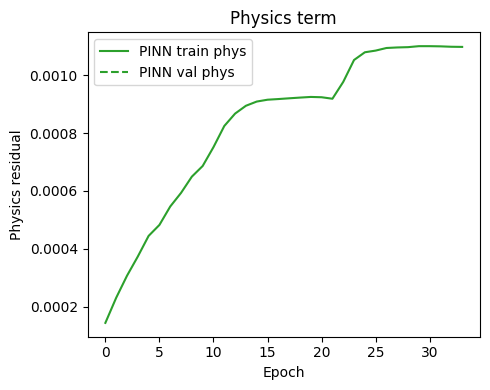

In [11]:
def plot_physics_curves(hist_pinn, title_prefix=""):
    if 'train_phys' in hist_pinn and 'val_phys' in hist_pinn:
        plt.figure(figsize=(5,4))
        plt.plot(hist_pinn['train_phys'], label='PINN train phys', color='tab:green')
        plt.plot(hist_pinn['val_phys'],   label='PINN val phys',   color='tab:green', linestyle='--')
        plt.xlabel('Epoch'); plt.ylabel('Physics residual'); plt.title(f'{title_prefix}Physics term'); plt.legend()
        plt.tight_layout(); plt.show()
    else:
        print("Physics residuals not logged in history; add logging in the training loop to plot.")

plot_physics_curves(res_pinn['history'], title_prefix="")


In [12]:
import numpy as np
import torch
from sklearn.metrics import roc_auc_score

@torch.no_grad()
def get_test_probs(model, loader, device='cuda'):
    model.eval()
    y_true, y_prob = [], []
    for imgs, lbls in loader:
        imgs = imgs.to(device, non_blocking=True)
        lbls = lbls.to(device, non_blocking=True)
        logits, _ = model(imgs)
        prob = torch.softmax(logits, dim=1)
        y_true.extend(lbls.cpu().numpy().tolist())
        y_prob.append(prob.cpu().numpy())
    y_true = np.array(y_true)
    y_prob = np.concatenate(y_prob, axis=0)
    return y_true, y_prob

y_true_b, prob_b = get_test_probs(res_base['model'], test_loader, device=device)
y_true_p, prob_p = get_test_probs(res_pinn['model'], test_loader, device=device)
assert np.array_equal(y_true_b, y_true_p)
y_true = y_true_b

auc_base = roc_auc_score(y_true, prob_b, multi_class='ovr', average='macro')
auc_pinn = roc_auc_score(y_true, prob_p, multi_class='ovr', average='macro')
print(f"ROC-AUC macro — BASE: {auc_base:.4f} | PINN: {auc_pinn:.4f}")


ROC-AUC macro — BASE: 0.9964 | PINN: 0.9944


Baseline calibration (first up to 5 classes):


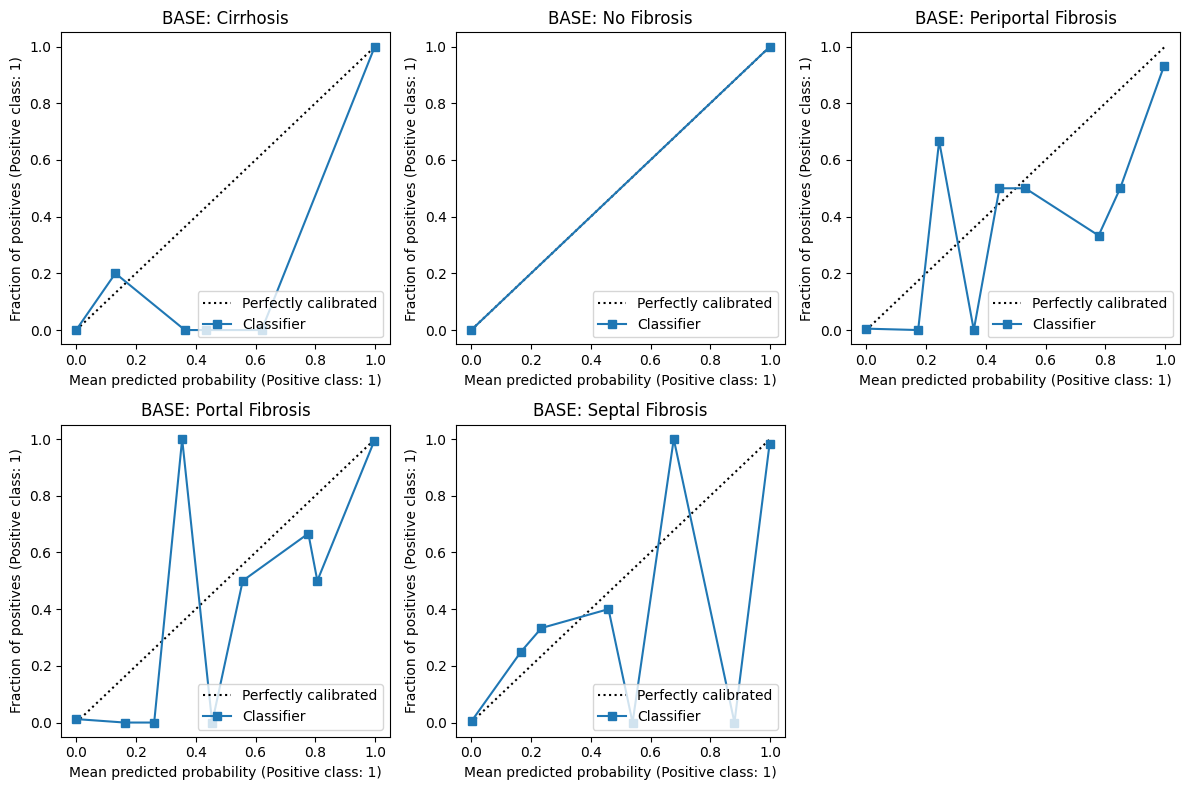

PINN calibration (first up to 5 classes):


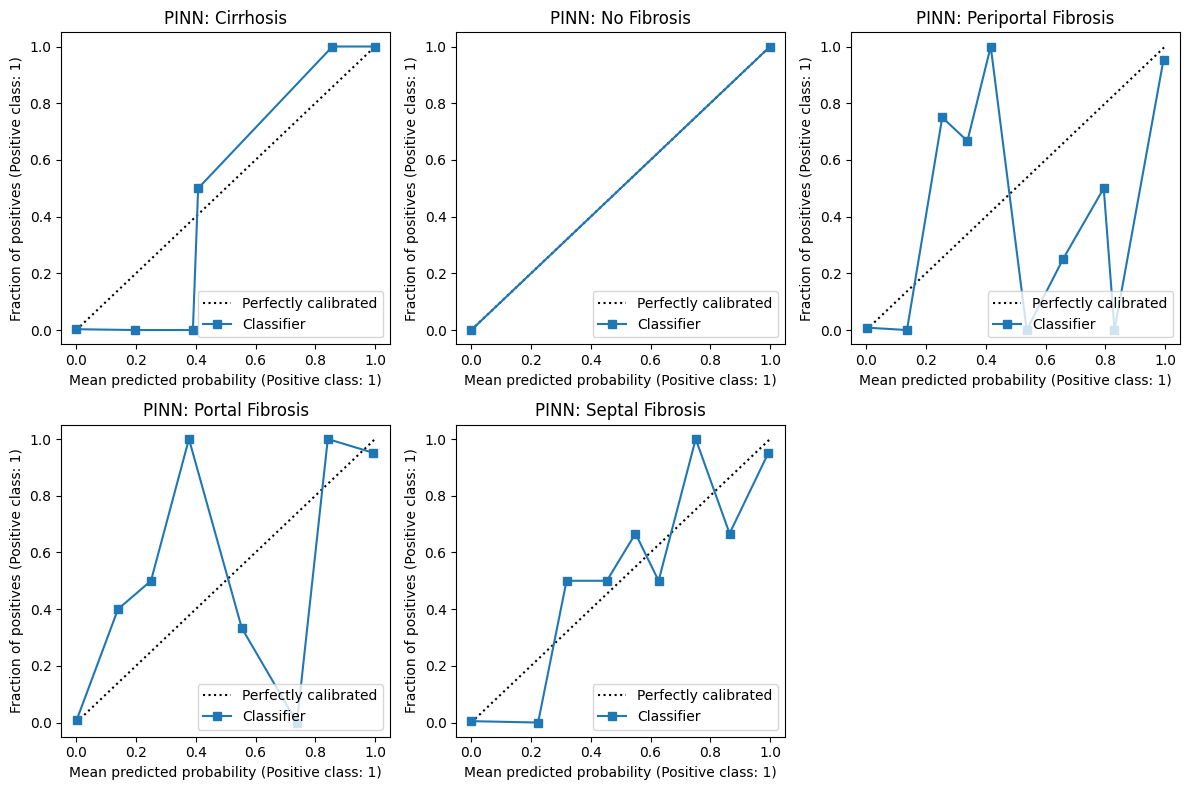

In [13]:
import matplotlib.pyplot as plt
from sklearn.calibration import CalibrationDisplay

def plot_calibration_ovr(y_true, y_prob, class_names, max_classes=5, n_bins=10, title='Calibration'):
    # Expect y_prob shape (n_samples, n_classes)
    if y_prob.ndim != 2:
        raise ValueError(f"Expected y_prob to be 2D (n_samples, n_classes), got shape {y_prob.shape}")
    if y_prob.shape[1] != len(class_names):  # FIX: use index 1
        raise ValueError(f"len(class_names)={len(class_names)} != y_prob.shape[1]={y_prob.shape[1]}")

    K = y_prob.shape[1]  # number of classes
    m = min(K, max_classes)
    cols = min(3, m); rows = int(np.ceil(m / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows), squeeze=False)
    ax_iter = (ax for row in axes for ax in row)

    for i in range(m):
        ax = next(ax_iter)
        y_bin = (y_true == i).astype(int)  # one-vs-rest for class i
        CalibrationDisplay.from_predictions(
            y_bin, y_prob[:, i], n_bins=n_bins, strategy='uniform', ax=ax
        )
        ax.set_title(f"{title}: {class_names[i]}")

    # Remove any unused axes cleanly
    for ax in ax_iter:
        fig.delaxes(ax)

    plt.tight_layout()
    plt.show()
# Class names must match your ImageFolder mapping order
class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

print("Baseline calibration (first up to 5 classes):")
plot_calibration_ovr(y_true, prob_b, class_names, max_classes=5, title='BASE')

print("PINN calibration (first up to 5 classes):")
plot_calibration_ovr(y_true, prob_p, class_names, max_classes=5, title='PINN')


In [14]:
# Save base model state
torch.save(res_base['model'].state_dict(), 'base_model.pth')

# Save physics-informed model state
torch.save(res_pinn['model'].state_dict(), 'pinn_model.pth')

In [7]:
# Create fresh instances (must match the original model class and init args)
base_model = ResNet50PINN(num_classes=len(CFG.disease_types))
pinn_model = ResNet50PINN(num_classes=len(CFG.disease_types))

# Load saved weights
base_model.load_state_dict(torch.load('base_model.pth', map_location=device))
pinn_model.load_state_dict(torch.load('pinn_model.pth', map_location=device))

# Move to device and eval mode
base_model.to(device).eval()
pinn_model.to(device).eval()

# If models were wrapped in DataParallel when saving,
# after loading the state_dict as above, do NOT wrap again unless needed.

ResNet50PINN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2

In [8]:
def extract_logits(out):
    # Descend through nested tuple/list to find first 2D tensor (B,K)
    visited = set()
    stack = [out]
    while stack:
        cur = stack.pop(0)
        # Avoid infinite loops if someone accidentally passes the same container
        if id(cur) in visited:
            continue
        visited.add(id(cur))
        if isinstance(cur, torch.Tensor):
            if cur.ndim == 2:    # logits (B, K)
                return cur
            if cur.ndim == 1:    # (K,) -> (1,K)
                return cur.unsqueeze(0)
            # If tensor but not 1D/2D logits, skip
        elif isinstance(cur, (tuple, list)):
            stack.extend(list(cur))
        elif isinstance(cur, dict):
            # common key names
            for k in ('logits','output','out'):
                if k in cur:
                    stack.append(cur[k])
            # append other values too
            stack.extend(list(cur.values()))
        # else: ignore other types
    raise TypeError(f"Could not find logits tensor in model output; got type {type(out)}")

@torch.no_grad()
def preprocess_image(path, size=CFG.image_size, device=device):
    from PIL import Image
    import torchvision.transforms.functional as TF
    img = Image.open(path).convert('L')
    img = TF.resize(img, (size, size))
    x = TF.to_tensor(img).repeat(3,1,1)
    x = TF.normalize(x, [0.485,0.456,0.406],[0.229,0.224,0.225])
    return x.unsqueeze(0).to(device)

In [9]:
from captum.attr import IntegratedGradients, NoiseTunnel
import numpy as np

if hasattr(base_model, 'module'): base_model = base_model.module
if hasattr(pinn_model, 'module'): pinn_model = pinn_model.module
base_model.eval(); pinn_model.eval()

def f_base(x):
    out = base_model(x)
    return extract_logits(out)

def f_pinn(x):
    out = pinn_model(x)
    return extract_logits(out)

with torch.no_grad():
    dummy = torch.zeros(1, 3, CFG.image_size, CFG.image_size, device=device)
    out_b = f_base(dummy)
    out_p = f_pinn(dummy)
    assert isinstance(out_b, torch.Tensor) and out_b.ndim == 2, f"f_base returned {type(out_b)} shape {getattr(out_b,'shape',None)}"
    assert isinstance(out_p, torch.Tensor) and out_p.ndim == 2, f"f_pinn returned {type(out_p)} shape {getattr(out_p,'shape',None)}"

def ig_attribution_forward(forward_fn, x, target=None, smooth=True):
    with torch.no_grad():
        logits = forward_fn(x)
        if not isinstance(logits, torch.Tensor) or logits.ndim != 2:
            raise ValueError(f"Expected logits tensor (B,K), got {type(logits)} with shape {getattr(logits,'shape',None)}")
        if target is None:
            target = int(logits.argmax(1).item())
    ig = IntegratedGradients(forward_fn)
    baseline = torch.zeros_like(x)
    if smooth:
        nt = NoiseTunnel(ig)
        attr = nt.attribute(x, baselines=baseline, target=target,
                            nt_type='smoothgrad', nt_samples=25, stdevs=0.1)
    else:
        attr = ig.attribute(x, baselines=baseline, target=target)
    attr = attr.squeeze(0).mean(0).detach().cpu().numpy()
    return attr, target


Image: /content/Resized_Dataset/Cirrhosis/F5433.jpg
BASE predicted target=0 (Cirrhosis)
PINN predicted target=0 (Cirrhosis)


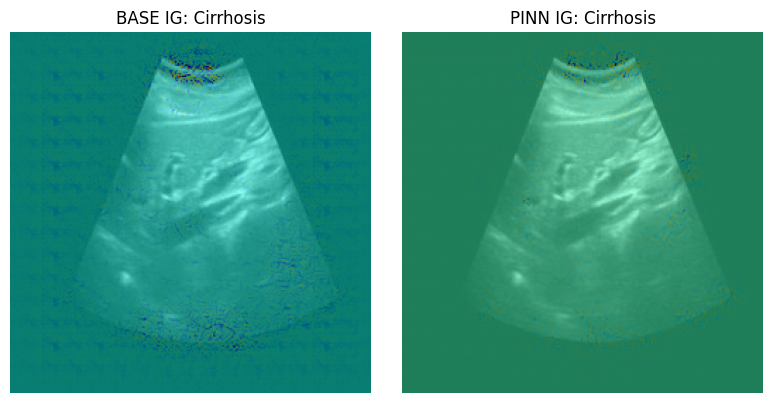

Image: /content/Resized_Dataset/Portal Fibrosis/A9777.jpg
BASE predicted target=3 (Portal Fibrosis)
PINN predicted target=3 (Portal Fibrosis)


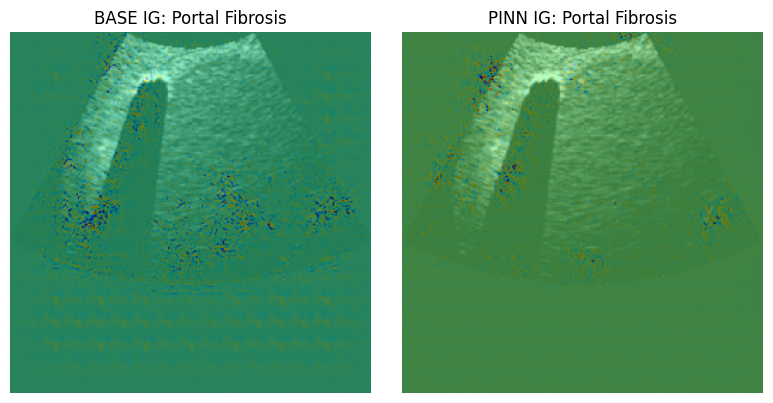

In [15]:
class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

sample_paths = [
    f"{CFG.data_dir}/Cirrhosis/F5433.jpg",
    f"{CFG.data_dir}/Portal Fibrosis/A9777.jpg",
]

for p in sample_paths:
    x = preprocess_image(p, device=device)

    attr_b, tgt_b = ig_attribution_forward(f_base, x, target=None, smooth=False)
    attr_p, tgt_p = ig_attribution_forward(f_pinn, x, target=None, smooth=False)

    print(f"Image: {p}")
    print(f"BASE predicted target={tgt_b} ({class_names[tgt_b]})")
    print(f"PINN predicted target={tgt_p} ({class_names[tgt_p]})")

    # Side-by-side overlays
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    img_np = x.squeeze(0).mean(0).detach().cpu().numpy()
    am_b = (attr_b - attr_b.min()) / (attr_b.ptp() + 1e-8)
    am_p = (attr_p - attr_p.min()) / (attr_p.ptp() + 1e-8)

    axes[0].imshow(img_np, cmap='gray')
    axes[0].imshow(am_b, cmap='jet', alpha=0.5)
    axes[0].set_title(f"BASE IG: {class_names[tgt_b]}")
    axes[0].axis('off')

    axes[1].imshow(img_np, cmap='gray')
    axes[1].imshow(am_p, cmap='jet', alpha=0.5)
    axes[1].set_title(f"PINN IG: {class_names[tgt_p]}")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()
